<a href="https://colab.research.google.com/github/IsaacFigNewton/CommitteeHearingDiscourseParser/blob/main/DH2024_DigitalDemocracy_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Accessing & working with the Digital Democracy Corpus: Comprehensive Proceedings of Four State Legislatures 2015-2018


This notebook will act as a guide for a person with minimal knowledge of coding to make use of the files and retrieve useful information from the corpus.


The dataset can be downloaded directly from this website: https://huggingface.co/datasets/iatpp/digitaldemocracy-2015-2018

This corpus is distributed under the cc-by-nc-sa-4.0 license. Please review before accessing. https://creativecommons.org/licenses/by-nc-sa/4.0/

Please cite as:

Khosmood, F., Dekhtyar, A., Ellwein, S., White, B., "The Digital Democracy Corpus: Comprehensive Proceedings of Four State Legislatures 2015-2018", Digital Humanities, Washington, DC, August 2024.

# Download files

The Digital Democracy Corpus can be downloaded from here: https://huggingface.co/datasets/iatpp/digitaldemocracy-2015-2018

In [1]:
from pathlib import Path
import subprocess
import zipfile
import os

#This is where the unzipped corpus file is stored
CORPUS_FILE_PATH = 'DH2024_Corpus_Release/'
corpus_dir = Path(CORPUS_FILE_PATH)
zip_path = Path("digitaldemocracy-2015-2018/DH2024_Corpus_Release.zip")
repo_dir = Path("digitaldemocracy-2015-2018")

# Clone repository if not present
if not repo_dir.is_dir():
    print("Corpus directory not found. Cloning repository...")
    subprocess.run(
        ["git", "clone", "https://huggingface.co/datasets/iatpp/digitaldemocracy-2015-2018"],
        check=True,
    )
    print("Repository cloned successfully.")

# Extract zip file if corpus directory doesn't exist
if not corpus_dir.is_dir():
    if zip_path.exists():
        print(f"Extracting {zip_path}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall('.')
        print("Extraction complete.")
    else:
        print(f"Error: {zip_path} not found!")
else:
    print(f"Corpus already extracted at {corpus_dir}")

Corpus already extracted at DH2024_Corpus_Release


# Import and config

In [2]:
from src.constants.constants import UNKNOWN
from src import HearingLoader, HearingTagger, ClassifierPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

tokens = [ClassifierPipeline.TOKEN_COL]
text_features = [ClassifierPipeline.TEXT_COL]
categorical_features = ClassifierPipeline.CAT_COLS
numeric_features = ClassifierPipeline.NUM_COLS

# Initialize the HearingLoader with the corpus path
loader = HearingLoader(corpus_path='DH2024_Corpus_Release/')
tagger = HearingTagger()

# Discussion Transcripts

In [3]:
# discussion will contain all the information from bill CA_201720180AB10 in hearing id 51835
# 'CA_201720180AB10': ['51835',
#   '52298',
#   '52708',
#   '52856',
#   '53960',
#   '54363',
#   '54505']
hearing = loader.bill_discussion_info(51835, "CA_201720180AB10")
print(hearing)

State:		CA
Committee:	Assembly Standing Committee on Education
Bill:		CA_201720180AB10
Date:		2017-03-15


Transcript:
Patrick O'Donnell: [UNKNOWN]:
She'll be presenting AB 10, file item number one.


Cristina Garcia: [UNKNOWN]:
Thank you. Good afternoon Chair and members. I'm here presenting AB 10 would require vital menstrual products, pads, and tampons to be provided in school, colleges, shelters throughout the state. Menstrual products are a basic necessity similar to toilet paper. As early as the fourth grade young girls get their period and may not be prepared nor understand the natural changes of their bodies many of these young girls end up missing school three to five days a month on a regular basis, because they lack basic access to these products. No young girl should ever have to miss school because she does not have access to these basic health needs. For some young girls, access to these products is an additional barrier to their education. It's also loss of funding for s

# Try loading all the hearings

In [4]:
hearings = loader.load_all_committee_hearings()
relevant_hearings = [h for h in hearings if h.bid != 'CA_NO BILL DISCUSSED']
print(len(hearings))
print(len(relevant_hearings))

invalid literal for int() with base 10: 'hid'
invalid literal for int() with base 10: 'hid'
invalid literal for int() with base 10: 'hid'
8218
7069


In [5]:
import random

# Set random seed for reproducibility
random.seed(42)

# Randomly sample 100 hearings
sampled_hearings = random.sample(relevant_hearings, 100)
sampled_hearings = [tagger(h) for h in sampled_hearings]
if sampled_hearings is None:
    raise ValueError("tagger returned no valid hearings from random sample")

# Build utterances dataframe from the sampled hearings using the new public method
# This automatically sorts by state, bid, hid, uid and fills missing values
utterances_df = ClassifierPipeline._build_utterances_dataframe(sampled_hearings)

# save it to a csv
utterances_df.to_csv('./utterances_sample.csv', index=False)

In [6]:
import pandas as pd

utterances_df = pd.read_csv('./utterances_sample.csv')
labeled_utterances_df = pd.read_csv('./utterances_sample_labeled.csv')

In [7]:
nontoken_feature_cols = [
    c for c in utterances_df.columns
    if c not in labeled_utterances_df.columns
]
labeled_utterances_df[nontoken_feature_cols] = utterances_df[nontoken_feature_cols]

In [8]:
labeled_utterances_df.head()

,state,bid,hid,uid,pid,speaker.position,section,text,speaker.position.value,can_file_motions,is_presenter,relative_position,token_count,sent_count,mentions_speaker,mentions_bill,speech_act_cues,section_cues
0,CA,CA_201520160AB2050,255341,0,55,PRESIDING_CHAIR,INTRO,ORG woman LEGISLATOR you have three matters if...,8.0,True,False,0.000000,83,5,1,1,NaN,NaN
1,CA,CA_201520160AB2050,255341,1,101330,BILL_AUTHOR,PRESENTATION,good morning mr chair and members thank you fo...,4.0,False,True,0.022727,373,18,0,1,NaN,NaN
2,CA,CA_201520160AB2050,255341,2,55,PRESIDING_CHAIR,PRESENTATION,that is correct what they've been doing we've ...,8.0,True,False,0.045455,24,3,0,0,NaN,NaN
3,CA,CA_201520160AB2050,255341,3,101330,BILL_AUTHOR,PRESENTATION,that's correct,4.0,False,True,0.068182,2,1,0,0,NaN,NaN
4,CA,CA_201520160AB2050,255341,4,55,PRESIDING_CHAIR,PRESENTATION,and this is plan step two I guess or new step two,8.0,True,False,0.090909,13,1,0,0,NaN,NaN


In [9]:
labeled_utterances_df['section'].value_counts()

section
PUBLIC_COMMENTS          753
LEGISLATOR_DISCUSSION    742
VOTE                     249
EXPERT_TESTIMONY         208
CLOSING_REMARKS          191
PRESENTATION             139
OTHER_HEARING            102
INTRO                     86
OTHER_PROCEDURAL          81
OTHER_NONPROCEDURAL       67
Col 7: section             1
Name: count, dtype: int64

# Evaluation

## Config

In [10]:
# Create classifiers
lr_classifier = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    solver='lbfgs'
)

mlp_classifier = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    max_iter=2000,
    random_state=42,
    solver='adam'
)

# Create parsers with different classifiers
parser_lr = ClassifierPipeline(
    base_estimator=lr_classifier,
    masking=True,
    smoothing=False
)
parser_mlp = ClassifierPipeline(
    base_estimator=mlp_classifier,
    masking=True,
    smoothing=False
)

In [11]:
from sklearn.model_selection import GroupShuffleSplit

# Create a combined group identifier for bid+hid
labeled_utterances_df['hearing_group'] = labeled_utterances_df['bid'].astype(str) + '_' + labeled_utterances_df['hid'].astype(str)

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=69,
)

train_idx, test_idx = next(
    splitter.split(
        labeled_utterances_df, 
        labeled_utterances_df['section'], 
        groups=labeled_utterances_df['hearing_group']
    )
)

train_df = labeled_utterances_df.iloc[train_idx].copy()
test_df = labeled_utterances_df.iloc[test_idx].copy()

print('Train rows:', len(train_df))
print('Test rows:', len(test_df))
print('Train hearings:', train_df['hearing_group'].nunique())
print('Test hearings:', test_df['hearing_group'].nunique())

# Initialize test_hearings_grouped structure (features will be added later)
test_hearings_grouped = {}
for hearing_id in test_df['hearing_group'].unique():
    hearing_data = test_df[test_df['hearing_group'] == hearing_id].sort_values('uid')
    test_hearings_grouped[hearing_id] = {
        'y': hearing_data['section'],
        'hearing_len': len(hearing_data),
        'bid': hearing_data['bid'].iloc[0],
        'hid': hearing_data['hid'].iloc[0]
    }

print(f'Test hearings grouped: {len(test_hearings_grouped)}')

Train rows: 2010
Test rows: 609
Train hearings: 75
Test hearings: 25
Test hearings grouped: 25


In [12]:
# Fill missing values in labeled data for train/test splits
for col in numeric_features:
  labeled_utterances_df[col] = labeled_utterances_df[col].fillna(0)
  train_df[col] = train_df[col].fillna(0)
  test_df[col] = test_df[col].fillna(0)

for col in categorical_features:
  labeled_utterances_df[col] = labeled_utterances_df[col].fillna(UNKNOWN)
  train_df[col] = train_df[col].fillna(UNKNOWN)
  test_df[col] = test_df[col].fillna(UNKNOWN)

In [13]:
# Prepare train and test data
feature_cols = tokens + text_features + categorical_features + numeric_features

X_train = train_df[feature_cols]
y_train = train_df['section']

X_test = test_df[feature_cols]
y_test = test_df['section']

# Update test_hearings_grouped with complete hearing data (features + metadata)
for hearing_id in test_hearings_grouped:
    hearing_data = test_df[test_df['hearing_group'] == hearing_id].sort_values('uid').copy()
    # Store the complete hearing data, not just features
    test_hearings_grouped[hearing_id]['data'] = hearing_data

## Training models

In [14]:
# Train both models using HearingParser's train_model method
print("Training Logistic Regression model...")
parser_lr.train_model(train_df, label_col='section')

print("Training MLP classifier model...")
parser_mlp.train_model(train_df, label_col='section')

Training Logistic Regression model...
Training MLP classifier model...


In [15]:
import numpy as np
from sklearn.metrics import classification_report

# Define label order from SectionEnum
label_order = [
    'INTRO',
    'PRESENTATION',
    'LEGISLATOR_DISCUSSION',
    'EXPERT_TESTIMONY',
    'PUBLIC_COMMENTS',
    'CLOSING_REMARKS',
    'VOTE',
    'OTHER_HEARING',
    'OTHER_PROCEDURAL',
    'OTHER_NONPROCEDURAL'
]

# Get unique hearings in test set
test_hearings_info = test_df[['bid', 'hid']].drop_duplicates()

# Match test hearings to sampled_hearings objects
test_hearings = []
for _, row in test_hearings_info.iterrows():
    for hearing in sampled_hearings:
        if hearing.bid == row['bid'] and hearing.hid == row['hid']:
            test_hearings.append(hearing)
            break

## Evaluation Results

For utterance-level predictions (no hearing context), we can't measure parse success

Parse success is a hearing-level property, not utterance-level

In [16]:
# Evaluate Logistic Regression model
print("=" * 80)
print("LOGISTIC REGRESSION MODEL EVALUATION")
print("=" * 80)

# Perform sequence-based prediction using grouped hearings
pred_lr_grouped = {}
for hearing_id, data in test_hearings_grouped.items():
    # Get corresponding hearing object
    hearing = None
    for h in sampled_hearings:
        if h.bid == data['bid'] and h.hid == data['hid']:
            hearing = h
            break
    
    if hearing is None:
        print(f"Warning: Could not find hearing object for {hearing_id}")
        continue
    
    # Predict using new interface with pre-filtered hearing data
    labels = parser_lr.predict_hearing_sections(
        hearing=hearing,
        hearing_df=data['data'],
    )
    pred_lr_grouped[hearing_id] = labels

# Flatten predictions while preserving order
pred_lr_flat = []
for hearing_id in test_df['hearing_group'].unique():
    if hearing_id in pred_lr_grouped:
        pred_lr_flat.extend(pred_lr_grouped[hearing_id])

pred_lr = np.array(pred_lr_flat)

print(classification_report(
    y_test,
    pred_lr,
    labels=label_order,
    digits=3,
))

LOGISTIC REGRESSION MODEL EVALUATION
                       precision    recall  f1-score   support

                INTRO      0.667     0.667     0.667        27
         PRESENTATION      0.529     0.643     0.581        28
LEGISLATOR_DISCUSSION      0.751     0.866     0.804       209
     EXPERT_TESTIMONY      0.524     0.193     0.282        57
      PUBLIC_COMMENTS      0.860     0.842     0.851       139
      CLOSING_REMARKS      0.852     0.479     0.613        48
                 VOTE      0.644     0.580     0.611        50
        OTHER_HEARING      0.132     0.172     0.149        29
     OTHER_PROCEDURAL      0.188     0.667     0.293         9
  OTHER_NONPROCEDURAL      0.500     0.308     0.381        13

             accuracy                          0.677       609
            macro avg      0.565     0.542     0.523       609
         weighted avg      0.697     0.677     0.671       609



In [17]:
# Evaluate MLP model
print("\n" + "=" * 80)
print("MLP CLASSIFIER MODEL EVALUATION")
print("=" * 80)

# Perform sequence-based prediction using grouped hearings
pred_mlp_grouped = {}
for hearing_id, data in test_hearings_grouped.items():
    # Get corresponding hearing object
    hearing = None
    for h in sampled_hearings:
        if h.bid == data['bid'] and h.hid == data['hid']:
            hearing = h
            break
    
    if hearing is None:
        print(f"Warning: Could not find hearing object for {hearing_id}")
        continue
    
    # Predict using new interface with pre-filtered hearing data
    labels = parser_mlp.predict_hearing_sections(
        hearing=hearing,
        hearing_df=data['data'],
    )
    pred_mlp_grouped[hearing_id] = labels

# Flatten predictions while preserving order
pred_mlp_flat = []
for hearing_id in test_df['hearing_group'].unique():
    if hearing_id in pred_mlp_grouped:
        pred_mlp_flat.extend(pred_mlp_grouped[hearing_id])

pred_mlp = np.array(pred_mlp_flat)

print(classification_report(
    y_test,
    pred_mlp,
    labels=label_order,
    digits=3,
))


MLP CLASSIFIER MODEL EVALUATION
                       precision    recall  f1-score   support

                INTRO      0.750     0.444     0.558        27
         PRESENTATION      0.517     0.536     0.526        28
LEGISLATOR_DISCUSSION      0.701     0.885     0.782       209
     EXPERT_TESTIMONY      0.333     0.105     0.160        57
      PUBLIC_COMMENTS      0.761     0.871     0.812       139
      CLOSING_REMARKS      0.700     0.292     0.412        48
                 VOTE      0.702     0.660     0.680        50
        OTHER_HEARING      0.143     0.103     0.120        29
     OTHER_PROCEDURAL      0.167     0.556     0.256         9
  OTHER_NONPROCEDURAL      0.400     0.154     0.222        13

             accuracy                          0.650       609
            macro avg      0.517     0.461     0.453       609
         weighted avg      0.633     0.650     0.620       609



## Confusion Matrix

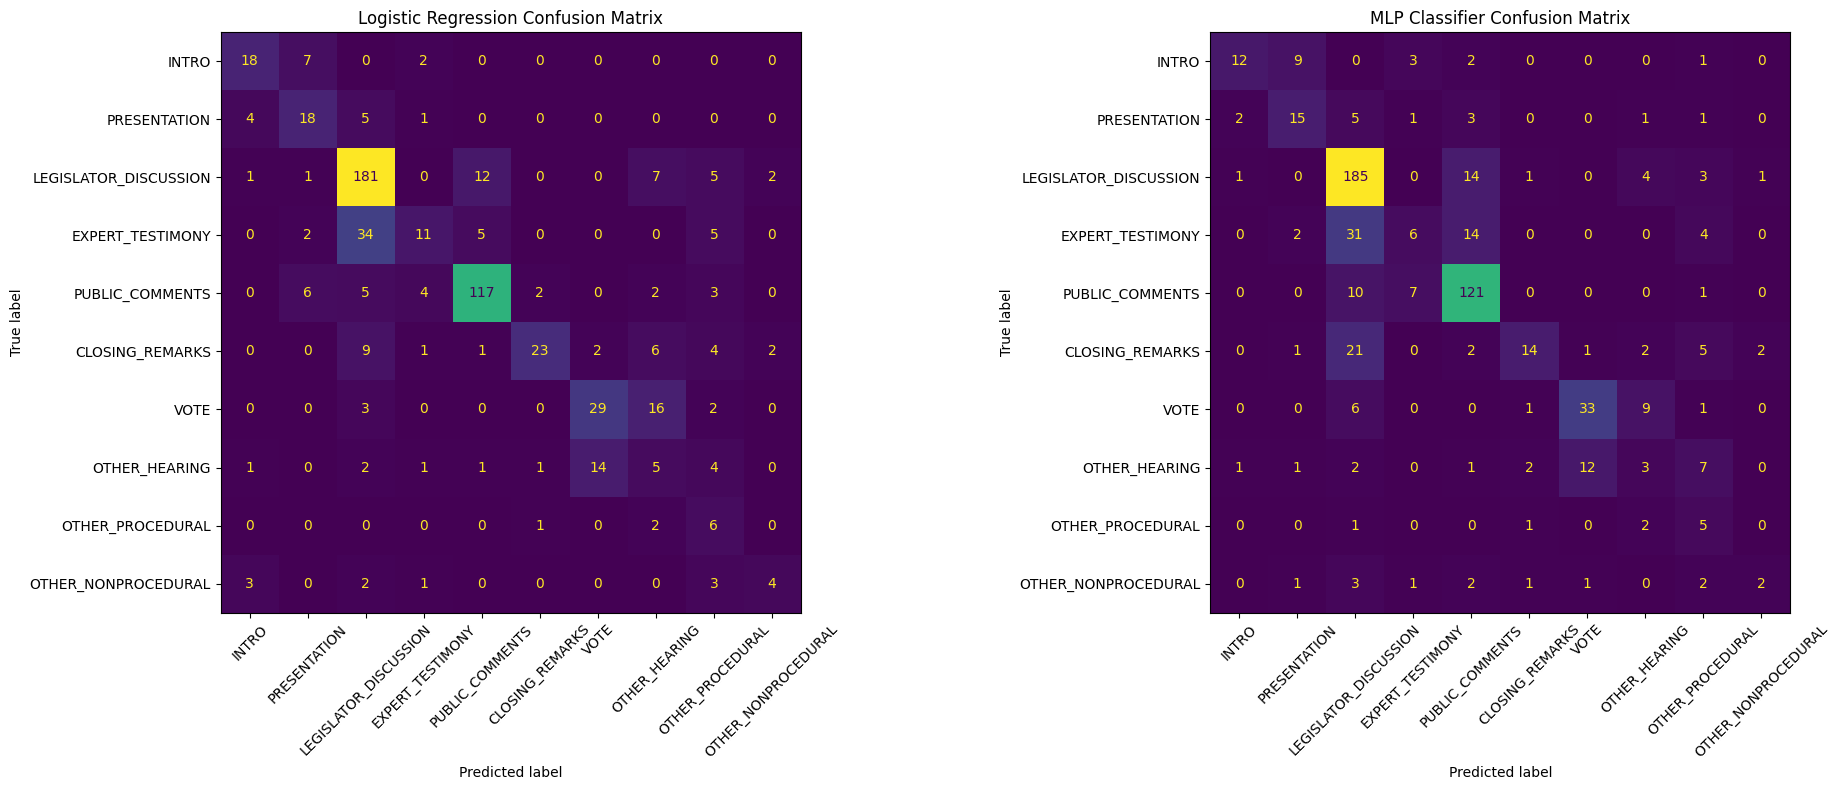

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Filter to only labels present in test set
labels = [label for label in label_order if label in y_test.unique()]

# Create side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Logistic Regression confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_lr,
    labels=labels,
    xticks_rotation=45,
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title('Logistic Regression Confusion Matrix')

# MLP confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_mlp,
    labels=labels,
    xticks_rotation=45,
    ax=axes[1],
    colorbar=False,
)
axes[1].set_title('MLP Classifier Confusion Matrix')

plt.tight_layout()
plt.show()

In [19]:
sample_hearing_id, sample_hearing_data = list(test_hearings_grouped.items())[0]

sample_hearing = None
for h in sampled_hearings:
    if h.bid == sample_hearing_data['bid'] and h.hid == sample_hearing_data['hid']:
        sample_hearing = h
        break
# Use the Logistic Regression parser's predict_hearing_sections method
labels_lr = parser_lr.predict_hearing_sections(
    hearing=sample_hearing,
    hearing_df=sample_hearing_data['data']
)

print("Logistic Regression predictions:")
print(labels_lr)

print("\n" + "=" * 80 + "\n")

# Use the MLP parser's predict_hearing_sections method
labels_mlp = parser_mlp.predict_hearing_sections(
    hearing=sample_hearing,
    hearing_df=sample_hearing_data['data']
)

print("MLP Classifier predictions:")
print(labels_mlp)

Logistic Regression predictions:
['INTRO', 'LEGISLATOR_DISCUSSION', 'OTHER_PROCEDURAL', 'OTHER_PROCEDURAL', 'EXPERT_TESTIMONY']


MLP Classifier predictions:
['PRESENTATION', 'OTHER_PROCEDURAL', 'OTHER_PROCEDURAL', 'OTHER_PROCEDURAL', 'PRESENTATION']


In [20]:
special_hearing = None
for h in sampled_hearings:
  if h.bid == 'CA_201720180AB2721':
    special_hearing = h
    break

Note: special case of Chairman presenting to someone else: Bill ID CA_201720180SB1293

Special kind of bill discussion: CA_201720180AB1708
Case where you have to use handoff cue: CA_201720180AB2721
CA_201720180SCR159

# Sanity Checks

In [21]:
print(sampled_hearings[0])

State:		CA
Committee:	Senate Standing Committee on Governance and Finance
Bill:		CA_201720180SCA22
Date:		2018-05-09


Transcript:
Mike McGuire: [PRESIDING_CHAIR]:
we're moving to BILL which is a constitutional amendment 22 senator BILL_AUTHOR this is in regards to school districts and parcel taxes we welcome the good senator the chair of education to the ORG the floor is yours sir


Benjamin Allen: [BILL_AUTHOR]:
members many of you know that I came to this position having served for two terms on school board in my hometown of GPE and I was elected in 2008 and literally I think that I was on the ballot for the november election and in october the stock market crashed the subprime mortgage hit full disaster mode and basically my entire time on the school board was spent trying to figure out ways to balance the budget keep our financial controls in place while also making sure we did everything we could to preserve and protect the core programs that made such a difference for our commun

In [22]:
def pprint_hearing_labels(hearing, hearing_df, labeled_utterances_df, parser, model_name=""):
  """Print formatted transcript with predicted section labels.
  
  Args:
      hearing: The hearing to print
      hearing_df: DataFrame with utterance features
      labeled_utterances_df: DataFrame with ground truth labels
      parser: HearingParser instance with trained model
      model_name: Name of the model for display purposes
  """
  pred_labels = parser.predict_hearing_sections(
    hearing=hearing,
    hearing_df=hearing_df,
  )
  
  # Filter labeled_utterances_df for this specific hearing
  hearing_labels = labeled_utterances_df[
    (labeled_utterances_df['bid'] == hearing.bid) & 
    (labeled_utterances_df['hid'] == hearing.hid)
  ].sort_values('uid')
  
  true_labels = hearing_labels['section'].values

  print()
  if model_name:
    print(f"Model: {model_name}")
  print(f"State:\t\t{hearing.state}")
  print(f"Committee:\t{hearing.cname}")
  print(f"Bill:\t\t{hearing.bid}")
  print(f"Date:\t\t{hearing.hearing_date.strftime('%Y-%m-%d')}")
  print()
  print("Transcript:")
  for i, contribution in enumerate(hearing.utterances):
    speaker = hearing.speakers[contribution.pid]
    print(f'Predicted label:\t[{pred_labels[i] if i < len(pred_labels) else "UNKNOWN"}]')
    print(f'True label:\t\t[{true_labels[i] if i < len(true_labels) else "UNKNOWN"}]')
    first_name = speaker.first_name or "UNKNOWN"
    last_name = speaker.last_name or "UNKNOWN"
    role = "UNKNOWN"
    if speaker.speaker_position:
      role = speaker.speaker_position.name
    name = f"{first_name} {last_name} [{role}]:"
    print(f"{name:<20}")
    print(f"\t{contribution.text}")
    print()
  print()

In [23]:
print("=" * 80)
print("LOGISTIC REGRESSION MODEL")
print("=" * 80)
pprint_hearing_labels(
    sample_hearing,
    sample_hearing_data['data'],
    labeled_utterances_df, parser_lr, "Logistic Regression")

print("\n" + "=" * 80)
print("MLP CLASSIFIER MODEL")
print("=" * 80)
pprint_hearing_labels(
    sample_hearing,
    sample_hearing_data['data'],
    labeled_utterances_df, parser_mlp, "MLP Classifier")

LOGISTIC REGRESSION MODEL

Model: Logistic Regression
State:		CA
Committee:	Assembly Standing Committee on Appropriations
Bill:		CA_201720180AB10
Date:		2017-05-26

Transcript:
Predicted label:	[INTRO]
True label:		[INTRO]
Lorena Gonzalez Fletcher [PRESIDING_CHAIR]:
	all right I see mr bonta walk in that means we can start good morning we can go now welcome to ORG ORG i'd like to welcome back mr quirk who is substituting for assemblywoman eggman and I would like to thank mr mccarty who is substituting for mr chau before we get started with the 531 bills on this suspense file which represents $215 billion in requests I like to thank my vice chair for his cooperation in moving these funds forward thank you mr COMMITTEE_MEMBER is there anything you would like to add

Predicted label:	[LEGISLATOR_DISCUSSION]
True label:		[OTHER_NONPROCEDURAL]
Franklin Bigelow [COMMITTEE_MEMBER]:
	yes i'd like to first thank the chairwoman for her leadership and her efforts in this part of the sessions acti